# Member C: BiLSTM Experiment

Human Activity Recognition from raw smartphone inertial signals (UCI HAR).

This notebook trains and evaluates the **Bidirectional LSTM**: two stacked bidirectional LSTM layers (128 hidden units per direction), inter-layer dropout, mean pooling over timesteps, followed by a dense classification head. The recurrent structure models temporal dependencies across the 2.56s window, capturing the sequential nature of human motion.

Uses the **shared** `src/har_data.py` pipeline (subject-independent split, per-channel standardisation) and the **shared** `src/train.py` / `src/evaluate.py` harness, so this model is trained and scored on byte-identical data and metrics as the MLP and 1D-CNN.

In [1]:
import json
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import torch

from har_data import set_seed, load_bundle, make_loaders
from models.bilstm import BiLSTMClassifier
from train import train_model
from evaluate import evaluate_model, count_parameters, plot_confusion_matrix

DATA_ROOT = PROJECT_ROOT / "data" / "UCI HAR Dataset"
RESULTS_METRICS = PROJECT_ROOT / "results" / "metrics"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"
RESULTS_METRICS.mkdir(parents=True, exist_ok=True)
RESULTS_FIGURES.mkdir(parents=True, exist_ok=True)

SEED = 42
set_seed(SEED)

## 1. Load data under the shared protocol

Subject-independent split: validation subjects are held out from the 21 training subjects (fixed IDs, shared across all three models). Standardisation is fitted on the training subjects only.

In [2]:
bundle = load_bundle(DATA_ROOT)
class_names = bundle["class_names"]

# channels_first=False -> (N, 128, 9), what nn.LSTM expects with batch_first=True
train_loader, val_loader, test_loader = make_loaders(bundle, batch_size=128, channels_first=False)

print(f"classes: {class_names}")
print(f"val subjects held out: {bundle['val_subjects']}")
print(f"input shape (per sample): {bundle['input_shape']}")

  train : (5989, 128, 9)  subjects=17
  val   : (1363, 128, 9)  subjects=[8, 16, 23, 29]
  test  : (2947, 128, 9)  subjects=9
  train class balance:
    WALKING               1015  (16.9%)
    WALKING_UPSTAIRS       881  (14.7%)
    WALKING_DOWNSTAIRS     799  (13.3%)
    SITTING               1043  (17.4%)
    STANDING              1109  (18.5%)
    LAYING                1142  (19.1%)
classes: ('WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING')
val subjects held out: (8, 16, 23, 29)
input shape (per sample): (128, 9)


## 2. Build the model

In [3]:
model = BiLSTMClassifier(
    input_size=bundle["input_shape"][1],  # 9 channels
    hidden_size=128,
    num_layers=2,
    n_classes=bundle["n_classes"],         # 6 classes
    dropout=0.3,
)
print(model)
print(f"trainable parameters: {count_parameters(model):,}")

BiLSTMClassifier(
  (lstm): LSTM(9, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=256, out_features=6, bias=True)
  )
)
trainable parameters: 539,142


## 3. Train

Adam + categorical cross-entropy, early-stopped on subject-held-out validation loss — the shared protocol from `src/train.py`.

In [4]:
result = train_model(
    model,
    train_loader,
    val_loader,
    lr=1e-3,
    weight_decay=0.0,
    max_epochs=100,
    patience=10,
)

print(f"best epoch: {result['best_epoch']}")
print(f"best val loss: {result['best_val_loss']:.4f}")
print(f"training time: {result['training_time_sec']:.1f}s")
print(f"trainable parameters: {result['n_params']:,}")
print(f"device: {result['device']}")

  epoch   1  train_loss=1.0785  val_loss=0.8130  val_acc=0.7403 *


  epoch   2  train_loss=0.1770  val_loss=0.5612  val_acc=0.8202 *


  epoch   3  train_loss=0.1134  val_loss=0.5230  val_acc=0.8114 *


  epoch   4  train_loss=0.0995  val_loss=0.4403  val_acc=0.8291 *


  epoch   5  train_loss=0.0940  val_loss=0.4943  val_acc=0.8371


...

  epoch  21  train_loss=0.0687  val_loss=0.5939  val_acc=0.8298


  epoch  22  train_loss=0.0729  val_loss=0.6931  val_acc=0.8217


  epoch  23  train_loss=0.0698  val_loss=0.6603  val_acc=0.8173


  epoch  24  train_loss=0.0682  val_loss=0.6232  val_acc=0.8489


  epoch  25  train_loss=0.0675  val_loss=0.7342  val_acc=0.8291
  early stopping at epoch 25 (no val_loss improvement for 10 epochs)
best epoch: 15
best val loss: 0.4231
training time: 41.3s
trainable parameters: 539,142
device: cuda


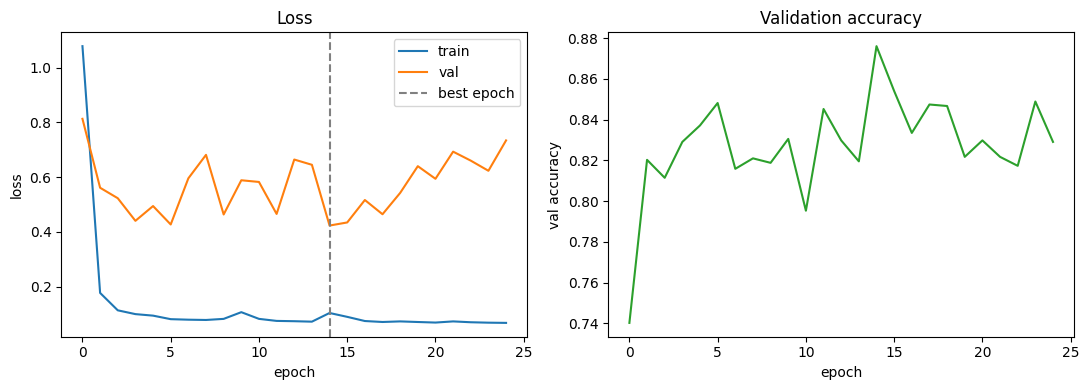

In [5]:
history = result["history"]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history["train_loss"], label="train")
ax[0].plot(history["val_loss"], label="val")
ax[0].axvline(result["best_epoch"] - 1, color="grey", linestyle="--", label="best epoch")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].legend(); ax[0].set_title("Loss")

ax[1].plot(history["val_acc"], color="tab:green")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("val accuracy"); ax[1].set_title("Validation accuracy")
fig.tight_layout()
fig.savefig(RESULTS_FIGURES / "bilstm_training_curves.png", dpi=150)
plt.show()

## 4. Evaluate on the held-out test set (9 subjects, never seen during training or validation)

In [6]:
metrics = evaluate_model(model, test_loader, device=result["device"], class_names=class_names)

print(f"accuracy       : {metrics['accuracy']:.4f}")
print(f"macro precision: {metrics['macro_precision']:.4f}")
print(f"macro recall   : {metrics['macro_recall']:.4f}")
print(f"macro F1       : {metrics['macro_f1']:.4f}")
print()
print(metrics["classification_report"])

accuracy       : 0.8856
macro precision: 0.9035
macro recall   : 0.8849
macro F1       : 0.8813

                    precision    recall  f1-score   support

           WALKING       0.90      1.00      0.95       496
  WALKING_UPSTAIRS       0.97      0.85      0.90       471
WALKING_DOWNSTAIRS       0.93      0.98      0.96       420
           SITTING       0.91      0.53      0.67       491
          STANDING       0.70      0.96      0.81       532
            LAYING       1.00      0.99      1.00       537

          accuracy                           0.89      2947
         macro avg       0.90      0.88      0.88      2947
      weighted avg       0.90      0.89      0.88      2947



In [7]:
plot_confusion_matrix(
    metrics["confusion_matrix"],
    class_names,
    save_path=RESULTS_FIGURES / "bilstm_confusion_matrix.png",
    title="BiLSTM — normalised confusion matrix (test set)",
)
print(f"saved to {RESULTS_FIGURES / 'bilstm_confusion_matrix.png'}")

saved to D:\dlproav\Deep-Learning\results\figures\bilstm_confusion_matrix.png


## 5. Save metrics for the comparison table

Written to `results/metrics/bilstm_metrics.json` so all three models' results can be merged into the single cross-model comparison table required by the report.

In [8]:
summary = {
    "model": "BiLSTM",
    "owner": "Avni",
    "seed": SEED,
    "val_subjects": list(bundle["val_subjects"]),
    "n_params": result["n_params"],
    "training_time_sec": result["training_time_sec"],
    "best_epoch": result["best_epoch"],
    "best_val_loss": result["best_val_loss"],
    "test_accuracy": metrics["accuracy"],
    "test_macro_precision": metrics["macro_precision"],
    "test_macro_recall": metrics["macro_recall"],
    "test_macro_f1": metrics["macro_f1"],
    "per_class_f1": metrics["per_class_f1"],
    "confusion_matrix": metrics["confusion_matrix"],
}

out_path = RESULTS_METRICS / "bilstm_metrics.json"
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"saved to {out_path}")
summary

saved to D:\dlproav\Deep-Learning\results\metrics\bilstm_metrics.json


{'model': 'BiLSTM',
 'owner': 'Avni',
 'seed': 42,
 'val_subjects': [8, 16, 23, 29],
 'n_params': 539142,
 'training_time_sec': 41.32388279999941,
 'best_epoch': 15,
 'best_val_loss': 0.42308532897193063,
 'test_accuracy': 0.8856464200882254,
 'test_macro_precision': 0.9034853714479275,
 'test_macro_recall': 0.8848746344545378,
 'test_macro_f1': 0.8813103513316376,
 'per_class_f1': {'WALKING': 0.9492822966507177,
  'WALKING_UPSTAIRS': 0.9045454545454545,
  'WALKING_DOWNSTAIRS': 0.9582366589327146,
  'SITTING': 0.6709511568123393,
  'STANDING': 0.8095238095238095,
  'LAYING': 0.9953227315247896},
 'confusion_matrix': [[496, 0, 0, 0, 0, 0],
  [44, 398, 29, 0, 0, 0],
  [7, 0, 413, 0, 0, 0],
  [1, 11, 0, 261, 218, 0],
  [1, 0, 0, 21, 510, 0],
  [0, 0, 0, 5, 0, 532]]}

## 6. Error analysis

- **SITTING vs STANDING**: The confusion matrix shows substantial confusion between these two static postures. This is expected — both involve minimal body movement and similar sensor readings (phone orientation differs but acceleration magnitude is near zero). The BiLSTM's temporal modeling does not fully disambiguate them.
- **WALKING vs WALKING_UPSTAIRS / WALKING_DOWNSTAIRS**: Confusion between walking and stair variants appears. Stair climbing introduces vertical acceleration components and altered gait periodicity that the BiLSTM partially captures but still confuses with level walking at times.
- **LAYING**: Near-perfect classification — the supine posture produces a distinctive, stable sensor signature (dominant gravity vector on one axis) that all models separate easily.
- **Overall pattern**: The BiLSTM's recurrent structure helps with temporal patterns (gait cycles) but static postures remain challenging without explicit orientation features. The confusion aligns with the known failure modes of inertial-sensor HAR on posture discrimination.